# Robustness Visualization

In [1]:
import sys
import os
import toml

In [2]:
from scipy.special import rel_entr
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np
import polars as pl
import torch
import torch.nn.functional as F
from ipywidgets import interactive, IntSlider

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [3]:
# plt.rcParams["text.usetex"] = True
# plt.rcParams["text.latex.preamble"] = r'\usepackage{amsmath}\usepackage{amssymb}'
# plt.rcParams["font.family"] = r'serif'
# plt.rcParams["font.serif"] = r'Computer Modern'

golden_ratio = (1 + 5 ** 0.5) / 2
cm_to_in = 1/2.54  # centimeters in inches
width = 8.45 * cm_to_in
height = width / golden_ratio

In [4]:
sys.path.append('..')

from axe.lcm.data.schema import LCMDataSchema
from axe.lcm.model.builder import LearnedCostModelBuilder
from axe.ltuner.data.schema import LTunerDataSchema
from axe.ltuner.model.builder import LTuneModelBuilder
from axe.lsm.types import Policy, LSMBounds, LSMDesign, System, Workload
from axe.lsm.cost import Cost
import axe.lsm.solver as Solvers

In [5]:
model_path = '../data/ltuner/models/robust_classic_tuner_sampler_111924_1144/'
cfg = toml.load(os.path.join(model_path, 'axe.toml'))
cfg["job"]["use_gpu_if_avail"] = False

In [6]:
bounds = LSMBounds(**cfg["lsm"]["bounds"])
policy = getattr(Policy, cfg["lsm"]["policy"])
categories = bounds.size_ratio_range[1] - bounds.size_ratio_range[0]
cost_fn = Cost(bounds.max_considered_levels)

In [7]:
# lcm = LearnedCostModelBuilder(
#     schema=lcm_schema, **cfg['lcm']['model']
# ).build(disable_one_hot_encoding=True)
# lcm.eval()
# lcm_weights = torch.load('../data/lcm/models/kaplsm_model/best_model.model', weights_only=True)
# status = lcm.load_state_dict(lcm_weights['model_state_dict'])
# status, lcm

In [8]:
def kl_div(wlx: Workload, wly: Workload):
    wlx = np.array([wlx.z0, wlx.z1, wlx.q, wlx.w])
    wly = np.array([wly.z0, wly.z1, wly.q, wly.w])
    return np.sum(rel_entr(wlx, wly))

## Testing Data

For now lets say all testing data generated by seed=0

In [9]:
def row_to_obj(row):
    workload = Workload(row['z0'], row['z1'], row['q'], row['w'])
    system = System(entries_per_page=row['entry_p_page'], selectivity=row['selec'],
                    entry_size=row['entry_size'], mem_budget=row['mem_budget'],
                    num_entries=row['num_elem'])
    return workload, system

In [10]:
expected_workloads = (
    Workload(z0=0.25, z1=0.25, q=0.25, w=0.25), # 00
    Workload(z0=0.97, z1=0.01, q=0.01, w=0.01), # 01
    Workload(z0=0.01, z1=0.97, q=0.01, w=0.01), # 02
    Workload(z0=0.01, z1=0.01, q=0.97, w=0.01), # 03
    Workload(z0=0.01, z1=0.01, q=0.01, w=0.97), # 04
    Workload(z0=0.49, z1=0.49, q=0.01, w=0.01), # 01
    Workload(z0=0.49, z1=0.01, q=0.49, w=0.01), # 06
    Workload(z0=0.49, z1=0.01, q=0.01, w=0.49), # 07
    Workload(z0=0.01, z1=0.49, q=0.49, w=0.01), # 08
    Workload(z0=0.01, z1=0.49, q=0.01, w=0.49), # 09
    Workload(z0=0.01, z1=0.01, q=0.49, w=0.49), # 10
    Workload(z0=0.33, z1=0.33, q=0.33, w=0.01), # 11
    Workload(z0=0.33, z1=0.33, q=0.01, w=0.33), # 12
    Workload(z0=0.33, z1=0.01, q=0.33, w=0.33), # 13
    Workload(z0=0.01, z1=0.33, q=0.33, w=0.33), # 14
)
# default_sys = System(num_entries=1e7, selectivity=0)
default_sys = System()

In [11]:
SEED = 0
NUM_SAMPLES = 1000

In [12]:
schema = LTunerDataSchema(policy=policy, bounds=bounds, seed=SEED, robust=True)
bench_table = []
for _ in tqdm(range(NUM_SAMPLES)):
    row = schema.sample_row_dict()
    row['entry_p_page'] = default_sys.entries_per_page
    row['selec'] = default_sys.selectivity
    row['entry_size'] = default_sys.entry_size
    row['mem_budget'] = default_sys.mem_budget
    row['num_elem'] = default_sys.num_entries
    bench_table.append(row)
bench_table = pl.DataFrame(bench_table).drop('rho')
bench_table

  0%|          | 0/1000 [00:00<?, ?it/s]

z0,z1,q,w,entry_p_page,selec,entry_size,mem_budget,num_elem
f64,f64,f64,f64,i64,i64,i64,f64,f64
0.041,0.229,0.367,0.363,4,0,8192,10.0,1e7
0.544,0.272,0.119,0.065,4,0,8192,10.0,1e7
0.3,0.241,0.322,0.137,4,0,8192,10.0,1e7
0.384,0.231,0.032,0.353,4,0,8192,10.0,1e7
0.135,0.254,0.332,0.279,4,0,8192,10.0,1e7
…,…,…,…,…,…,…,…,…
0.705,0.066,0.196,0.033,4,0,8192,10.0,1e7
0.531,0.018,0.437,0.014,4,0,8192,10.0,1e7
0.884,0.016,0.032,0.068,4,0,8192,10.0,1e7


In [13]:
input_table = []
for wl_id, wl in enumerate(expected_workloads):
    for rho in [0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2]:
        row = {'wl_id': wl_id, 'rho': rho, 'z0': wl.z0, 'z1': wl.z1, 'q': wl.q, 'w': wl.w, 'entry_p_page': default_sys.entries_per_page,
               'selec': default_sys.selectivity, 'entry_size': default_sys.entry_size,
               'mem_budget': default_sys.mem_budget, 'num_elem': default_sys.num_entries}
        input_table.append(row)
input_table = pl.DataFrame(input_table)
input_table

wl_id,rho,z0,z1,q,w,entry_p_page,selec,entry_size,mem_budget,num_elem
i64,f64,f64,f64,f64,f64,i64,i64,i64,f64,f64
0,0.0,0.25,0.25,0.25,0.25,4,0,8192,10.0,1e7
0,0.25,0.25,0.25,0.25,0.25,4,0,8192,10.0,1e7
0,0.5,0.25,0.25,0.25,0.25,4,0,8192,10.0,1e7
0,0.75,0.25,0.25,0.25,0.25,4,0,8192,10.0,1e7
0,1.0,0.25,0.25,0.25,0.25,4,0,8192,10.0,1e7
…,…,…,…,…,…,…,…,…,…,…
14,1.0,0.01,0.33,0.33,0.33,4,0,8192,10.0,1e7
14,1.25,0.01,0.33,0.33,0.33,4,0,8192,10.0,1e7
14,1.5,0.01,0.33,0.33,0.33,4,0,8192,10.0,1e7


In [14]:
input_dataset = input_table.to_torch(
    return_type="dataset",
    features=schema.feat_cols(),
    label=schema.label_cols(),
    dtype=pl.Float32
)

## Build Model

In [15]:
ltuner = LTuneModelBuilder(
    schema=schema,
    **cfg['ltuner']['model']
).build(robust=True)
ltuner_weights = torch.load(
    os.path.join(model_path, 'best_model.model'),
    weights_only=True,
    map_location=torch.device('cpu')
)
status = ltuner.load_state_dict(ltuner_weights['model_state_dict'])
ltuner.eval()
ltuner, status

(RobustClassicTunerSampler(
   (in_norm): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (in_layer): Linear(in_features=10, out_features=64, bias=True)
   (relu): ReLU()
   (dropout): Dropout(p=0, inplace=False)
   (hidden): Sequential(
     (0): Linear(in_features=64, out_features=64, bias=True)
     (1): Linear(in_features=64, out_features=64, bias=True)
   )
   (t_decision): Linear(in_features=64, out_features=20, bias=True)
   (bits_decision): Linear(in_features=64, out_features=1, bias=True)
   (policy_decision): Linear(in_features=64, out_features=2, bias=True)
   (lagrangians): Sequential(
     (0): Linear(in_features=10, out_features=64, bias=True)
     (1): Linear(in_features=64, out_features=2, bias=True)
   )
 ),
 <All keys matched successfully>)

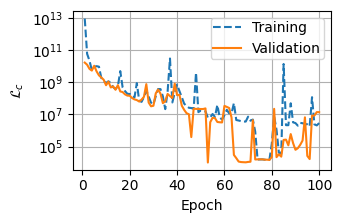

In [16]:
losses = pl.read_csv(os.path.join(model_path, 'losses.csv'))
# losses = losses.loc[0:]
fig, ax = plt.subplots(figsize=(width, height))
ax.plot(losses['epoch'], losses['train_loss'], label='Training', linestyle='--')
ax.plot(losses['epoch'], losses['test_loss'], label='Validation', linestyle='-')
ax.set_xlabel('Epoch')
ax.set_ylabel(r'$\mathcal{{L}}_c$')
ax.set_yscale('log')
ax.grid()
_ = ax.legend(loc='upper right', borderpad=0.2)

## Create Robust Tunings

In [35]:
def convert_ltune_out_to_design(out, schema):
    out = out.flatten()
    categories = schema.bounds.size_ratio_range[1] - schema.bounds.size_ratio_range[0]
    eta = out[0].item()
    lamb = out[1].item()
    bpe = out[2].item()
    size_ratio = out[3:3+categories].argmax().item() + schema.bounds.size_ratio_range[0]
    print(bpe)
    policy = out[-2:].argmax().item()
    
    return LSMDesign(bits_per_elem=bpe, size_ratio=size_ratio, policy=Policy(policy), kapacity=())

In [36]:
og_bounds = bounds
og_bounds.size_ratio_range = (2, 100)
solver = Solvers.ClassicSolver(og_bounds)

In [37]:
robust_tuner_designs = []
robust_solver_designs = []
nominal_solver_designs = []
for (feat, label) in tqdm(input_dataset, desc='Learned Tuner'):
    out = ltuner(feat.unsqueeze(0))
    design = convert_ltune_out_to_design(out, schema)
    robust_tuner_designs.append(design)
for row in tqdm(input_table.iter_rows(named=True), total=len(input_table), desc='Solver Tuner'):
    rho = row['rho']
    workload, system, = row_to_obj(row)
    design, _ = solver.get_nominal_design(system, workload)
    nominal_solver_designs.append(design)
    design, _ = solver.get_robust_design(system, workload, rho, init_args=[1, 1, design.bits_per_elem, design.size_ratio])
    robust_solver_designs.append(design)
# robust_tuner_designs, robust_solver_designs

Learned Tuner:   0%|          | 0/135 [00:00<?, ?it/s]

30.731002807617188
29.806743621826172
29.31477165222168
28.93103790283203
28.710411071777344
28.58351707458496
29.11922836303711
29.771211624145508
30.464962005615234
59.94855499267578
58.9637451171875
58.03350830078125
57.15972137451172
56.322940826416016
55.48616027832031
54.687583923339844
53.92034912109375
53.16014862060547
-5.087068557739258
-5.658153533935547
-5.804226398468018
-5.816739559173584
-5.729112148284912
-5.58240270614624
-5.267672538757324
-4.946161270141602
-4.754036903381348
29.964683532714844
31.190452575683594
32.41622543334961
33.641990661621094
34.86777114868164
36.093536376953125
37.228816986083984
38.21828842163086
39.21491241455078
73.99288940429688
73.79686737060547
73.60648345947266
73.47509765625
73.3437271118164
73.21234130859375
73.0874252319336
72.99354553222656
73.44265747070312
25.6827335357666
24.076858520507812
22.47715187072754
20.886127471923828
19.29069709777832
17.725997924804688
16.41583251953125
15.707636833190918
15.565428733825684
34.1578292

Solver Tuner:   0%|          | 0/135 [00:00<?, ?it/s]

In [20]:
df = []
for tuner_design, solver_design, nominal_design in zip(robust_tuner_designs, robust_solver_designs, nominal_solver_designs):
    df.append({'tuner_design': tuner_design, 'solver_design': solver_design, 'nominal_design': nominal_design})
df = pl.DataFrame(df)
design_table = pl.concat((input_table, df), how='horizontal')
design_table.head(5)

wl_id,rho,z0,z1,q,w,entry_p_page,selec,entry_size,mem_budget,num_elem,tuner_design,solver_design,nominal_design
i64,f64,f64,f64,f64,f64,i64,i64,i64,f64,f64,object,object,object
0,0.0,0.25,0.25,0.25,0.25,4,0,8192,10.0,1e7,"LSMDesign(bits_per_elem=30.731002807617188, size_ratio=9, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=3.210445130223234, size_ratio=5.808214644721535, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=3.2110053495416655, size_ratio=5.808035229139304, policy=<Policy.Leveling: 1>, kapacity=())"
0,0.25,0.25,0.25,0.25,0.25,4,0,8192,10.0,1e7,"LSMDesign(bits_per_elem=29.806743621826172, size_ratio=9, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=1.0, size_ratio=4.889243064401784, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=3.2110053495416655, size_ratio=5.808035229139304, policy=<Policy.Leveling: 1>, kapacity=())"
0,0.5,0.25,0.25,0.25,0.25,4,0,8192,10.0,1e7,"LSMDesign(bits_per_elem=29.31477165222168, size_ratio=9, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=1.0000000000000009, size_ratio=4.613045053605811, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=3.2110053495416655, size_ratio=5.808035229139304, policy=<Policy.Leveling: 1>, kapacity=())"
0,0.75,0.25,0.25,0.25,0.25,4,0,8192,10.0,1e7,"LSMDesign(bits_per_elem=28.93103790283203, size_ratio=9, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=1.0, size_ratio=4.286602186280644, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=3.2110053495416655, size_ratio=5.808035229139304, policy=<Policy.Leveling: 1>, kapacity=())"
0,1.0,0.25,0.25,0.25,0.25,4,0,8192,10.0,1e7,"LSMDesign(bits_per_elem=28.710411071777344, size_ratio=9, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=1.0000000000000004, size_ratio=4.0731065371369874, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=3.2110053495416655, size_ratio=5.808035229139304, policy=<Policy.Leveling: 1>, kapacity=())"


In [21]:
result_table = {'wl_id': [], 'rho': [], 'workload_0': [], 'workload_hat': [],
                'rho_hat': [], 'solver_cost': [], 'tuner_cost': [], 'nominal_cost': []}
for design_row in tqdm(design_table.iter_rows(named=True), total=len(design_table)):
    workload0, _, = row_to_obj(design_row)
    wl_id, rho = design_row['wl_id'], design_row['rho']
    for bench_row in bench_table.iter_rows(named=True):
        workload_hat, _ = row_to_obj(bench_row)
        result_table['wl_id'].append(wl_id)
        result_table['rho'].append(rho)
        result_table['workload_0'].append(workload0)
        result_table['workload_hat'].append(workload_hat)
        result_table['rho_hat'].append(kl_div(workload_hat, workload0))
        result_table['solver_cost'].append(cost_fn.calc_cost(design_row['solver_design'], default_sys, workload_hat))
        result_table['tuner_cost'].append(cost_fn.calc_cost(design_row['tuner_design'], default_sys, workload_hat))
        result_table['nominal_cost'].append(cost_fn.calc_cost(design_row['nominal_design'], default_sys, workload_hat))
result_table = pl.DataFrame(result_table)

  0%|          | 0/135 [00:00<?, ?it/s]

In [22]:
result_table = result_table.with_columns(
    solver_throughput=1/pl.col('solver_cost'),
    tuner_throughput=1/pl.col('tuner_cost'),
    nominal_throughput=1/pl.col('nominal_cost')
)
result_table = result_table.with_columns(
    delta_throughput=((pl.col('tuner_throughput') - pl.col('nominal_throughput')) / pl.col('nominal_throughput')),
    delta_throughput_solver=((pl.col('solver_throughput') - pl.col('nominal_throughput')) / pl.col('nominal_throughput'))
) 

In [23]:
result_table

wl_id,rho,workload_0,workload_hat,rho_hat,solver_cost,tuner_cost,nominal_cost,solver_throughput,tuner_throughput,nominal_throughput,delta_throughput,delta_throughput_solver
i64,f64,struct[4],struct[4],f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0.0,"{0.25,0.25,0.25,0.25}","{0.041,0.229,0.367,0.363}",0.182054,3.863286,NaN,3.863319,0.258847,NaN,0.258845,NaN,0.000008
0,0.0,"{0.25,0.25,0.25,0.25}","{0.544,0.272,0.119,0.065}",0.269997,1.350176,NaN,1.350134,0.740644,NaN,0.740667,NaN,-0.000031
0,0.0,"{0.25,0.25,0.25,0.25}","{0.3,0.241,0.322,0.137}",0.044953,2.467167,NaN,2.467172,0.405323,NaN,0.405322,NaN,0.000002
0,0.0,"{0.25,0.25,0.25,0.25}","{0.384,0.231,0.032,0.353}",0.202551,2.583273,NaN,2.583234,0.387106,NaN,0.387112,NaN,-0.000015
0,0.0,"{0.25,0.25,0.25,0.25}","{0.135,0.254,0.332,0.279}",0.045647,3.29148,NaN,3.291501,0.303815,NaN,0.303813,NaN,0.000006
…,…,…,…,…,…,…,…,…,…,…,…,…
14,2.0,"{0.01,0.33,0.33,0.33}","{0.705,0.066,0.196,0.033}",2.715887,2.108906,NaN,1.781235,0.47418,NaN,0.561408,NaN,-0.155375
14,2.0,"{0.01,0.33,0.33,0.33}","{0.531,0.018,0.437,0.014}",2.135356,2.899214,NaN,2.365935,0.344921,NaN,0.422666,NaN,-0.183939
14,2.0,"{0.01,0.33,0.33,0.33}","{0.884,0.016,0.032,0.068}",3.731472,1.65485,NaN,1.476954,0.604284,NaN,0.677069,NaN,-0.1075


In [27]:
def show_table(wl_id=0, rho=0):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    
    table = result_table.filter((pl.col('wl_id') == wl_id) & (pl.col('rho') == rho))
    pos = table.filter(pl.col('delta_throughput_solver') >= 0)
    neg = table.filter(pl.col('delta_throughput_solver') < 0)
    axes[0].scatter(pos['rho_hat'], pos['delta_throughput_solver'], s=5, color='tab:green')
    axes[0].scatter(neg['rho_hat'], neg['delta_throughput_solver'], s=5, color='tab:gray')
    axes[0].axhline(y=0, color='k', linestyle='--')
    axes[0].add_patch(mpatches.Rectangle((-1, 0), 6, 10, linewidth=1, color='tab:green', fill=True, alpha=0.20))
    axes[0].set_title('Solver')
    
    pos = table.filter(pl.col('delta_throughput') >= 0)
    neg = table.filter(pl.col('delta_throughput') < 0)
    axes[1].scatter(pos['rho_hat'], pos['delta_throughput'], s=5, color='tab:green')
    axes[1].scatter(neg['rho_hat'], neg['delta_throughput'], s=5, color='tab:gray')
    axes[1].axhline(y=0, color='k', linestyle='--')
    axes[1].add_patch(mpatches.Rectangle((-1, 0), 6, 10, linewidth=1, color='tab:green', fill=True, alpha=0.20))
    axes[1].set_title('Learned Tuner')
    min_y = table['delta_throughput_solver', 'delta_throughput'].min_horizontal().min()
    max_y = table['delta_throughput_solver', 'delta_throughput'].max_horizontal().max()
    # axes[0].set_ylim((min_y, max_y))
    # axes[1].set_ylim((min_y, max_y))
    
    fig.suptitle(f'$\\rho:$ {table['rho'][0]} | {table['workload_0'][0]}')
    fig.supxlabel(f'$I_{{KL}}(\\hat{{w}}, w)$')
    plt.show()

In [28]:
# iplot_env = interactive(show_table, wl_id=result_table['wl_id'].unique(), rho=result_table['rho'].unique())
iplot_env = interactive(show_table, wl_id=(0,14), rho=(0, 2, 0.25))
iplot_env

interactive(children=(IntSlider(value=0, description='wl_id', max=14), FloatSlider(value=0.0, description='rho…

In [26]:
design_table.filter((pl.col('wl_id') == 11))

wl_id,rho,z0,z1,q,w,entry_p_page,selec,entry_size,mem_budget,num_elem,tuner_design,solver_design,nominal_design
i64,f64,f64,f64,f64,f64,i64,i64,i64,f64,f64,object,object,object
11,0.0,0.33,0.33,0.33,0.01,4,0,8192,10.0,1e7,"LSMDesign(bits_per_elem=18.10614013671875, size_ratio=9, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=6.101106383923812, size_ratio=41.326012346761125, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=4.466480739244126, size_ratio=47.445077664996155, policy=<Policy.Leveling: 1>, kapacity=())"
11,0.25,0.33,0.33,0.33,0.01,4,0,8192,10.0,1e7,"LSMDesign(bits_per_elem=17.289390563964844, size_ratio=9, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=4.138000845816971, size_ratio=29.816235301190947, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=4.466480739244126, size_ratio=47.445077664996155, policy=<Policy.Leveling: 1>, kapacity=())"
11,0.5,0.33,0.33,0.33,0.01,4,0,8192,10.0,1e7,"LSMDesign(bits_per_elem=16.55511474609375, size_ratio=9, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=4.466480739244126, size_ratio=47.445077664996155, policy=<Policy.Tiering: 0>, kapacity=())","LSMDesign(bits_per_elem=4.466480739244126, size_ratio=47.445077664996155, policy=<Policy.Leveling: 1>, kapacity=())"
11,0.75,0.33,0.33,0.33,0.01,4,0,8192,10.0,1e7,"LSMDesign(bits_per_elem=15.859588623046875, size_ratio=9, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=1.0, size_ratio=8.610237182162955, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=4.466480739244126, size_ratio=47.445077664996155, policy=<Policy.Leveling: 1>, kapacity=())"
11,1.0,0.33,0.33,0.33,0.01,4,0,8192,10.0,1e7,"LSMDesign(bits_per_elem=15.457441329956055, size_ratio=9, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=1.0, size_ratio=7.901374201856363, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=4.466480739244126, size_ratio=47.445077664996155, policy=<Policy.Leveling: 1>, kapacity=())"
11,1.25,0.33,0.33,0.33,0.01,4,0,8192,10.0,1e7,"LSMDesign(bits_per_elem=15.954276084899902, size_ratio=9, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=4.466480739244126, size_ratio=47.445077664996155, policy=<Policy.Tiering: 0>, kapacity=())","LSMDesign(bits_per_elem=4.466480739244126, size_ratio=47.445077664996155, policy=<Policy.Leveling: 1>, kapacity=())"
11,1.5,0.33,0.33,0.33,0.01,4,0,8192,10.0,1e7,"LSMDesign(bits_per_elem=16.635099411010742, size_ratio=9, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=4.466480739244126, size_ratio=47.445077664996155, policy=<Policy.Tiering: 0>, kapacity=())","LSMDesign(bits_per_elem=4.466480739244126, size_ratio=47.445077664996155, policy=<Policy.Leveling: 1>, kapacity=())"
11,1.75,0.33,0.33,0.33,0.01,4,0,8192,10.0,1e7,"LSMDesign(bits_per_elem=17.414030075073242, size_ratio=9, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=4.466480739244126, size_ratio=47.445077664996155, policy=<Policy.Tiering: 0>, kapacity=())","LSMDesign(bits_per_elem=4.466480739244126, size_ratio=47.445077664996155, policy=<Policy.Leveling: 1>, kapacity=())"
11,2.0,0.33,0.33,0.33,0.01,4,0,8192,10.0,1e7,"LSMDesign(bits_per_elem=18.401981353759766, size_ratio=9, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=4.466480739244126, size_ratio=47.445077664996155, policy=<Policy.Tiering: 0>, kapacity=())","LSMDesign(bits_per_elem=4.466480739244126, size_ratio=47.445077664996155, policy=<Policy.Leveling: 1>, kapacity=())"
